# Automatic beta-modulation labeling

This notebook labels the continuous `.npz` signal using a **sample-level causal rolling RMS threshold** instead of non-overlapping 2-second RMS chunks.

Label convention:

- High-amplitude / high-power state → `0` = Idle
- Low-amplitude / low-power state → `1` = Beta

The important change is that labels are generated at the **sample level** from a **causal** rolling RMS/envelope threshold. At time `t`, the RMS value uses only the current and previous samples, not future samples. This prevents the threshold trace and labels from being shifted earlier by centered smoothing.


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Paths — keep these unchanged
# SCRIPT_PATH = Path('/content/drive/MyDrive/BCI/online classification/signal_generator/label.py')
# INPUT_NPZ = Path('/content/drive/MyDrive/BCI/online classification/signal_generator/cont_data.npz')
# OUTPUT_NPZ = Path('/content/drive/MyDrive/BCI/online classification/signal_generator/cont_data_labeled2.npz')
SCRIPT_PATH = Path('/content/drive/MyDrive/1 - BME PhD/BCI Lab/online classification/signal_generator/label.py')
INPUT_NPZ = Path('/content/drive/MyDrive/1 - BME PhD/BCI Lab/online classification/signal_generator/cont_data.npz')
OUTPUT_NPZ = Path('/content/drive/MyDrive/1 - BME PhD/BCI Lab/online classification/signal_generator/cont_data_labeled2.npz')

# Labeling parameters
# This replaces the old 2-second RMS chunking.
LABEL_METHOD = 'causal_rolling_rms_threshold'
ROLLING_RMS_SEC = 0.025
LABEL_THRESHOLD = 0.25   # lower RMS/envelope threshold; adjust if needed
HIGH_LABEL = 0           # Idle
LOW_LABEL = 1            # Beta

print('Input:', INPUT_NPZ)
print('Output:', OUTPUT_NPZ)
print('Label method:', LABEL_METHOD)
print('Causal rolling RMS window:', ROLLING_RMS_SEC, 's')
print('Threshold:', LABEL_THRESHOLD)
print('Class mapping: 0 = Idle/high amplitude, 1 = Beta/low amplitude')

Input: /content/drive/MyDrive/1 - BME PhD/BCI Lab/online classification/signal_generator/cont_data.npz
Output: /content/drive/MyDrive/1 - BME PhD/BCI Lab/online classification/signal_generator/cont_data_labeled2.npz
Label method: causal_rolling_rms_threshold
Causal rolling RMS window: 0.025 s
Threshold: 0.25
Class mapping: 0 = Idle/high amplitude, 1 = Beta/low amplitude


## Label the continuous signal directly

This cell loads `cont_data.npz`, computes a **causal rolling RMS/envelope** value at every sample, thresholds that continuous trace, and saves the resulting `sample_labels`.

This removes the old behavior:

```text
2-second chunk → one RMS value → one chunk label → repeated over samples
```

The new behavior is:

```text
continuous signal → causal rolling RMS/envelope at every sample → threshold → sample-level label
```

Causal means that the RMS value at sample `t` is computed only from samples up to and including `t`:

```text
x[t - window + 1 : t + 1]
```

It does **not** use future samples.


In [27]:
def rolling_rms_causal(x, window_samples):
    """Compute causal rolling RMS with the same output length as x.

    For each sample t, this returns:

        sqrt(mean(x[max(0, t-window_samples+1):t+1] ** 2))

    This is causal because the value at t uses only current/past samples.
    It does not use centered convolution and does not look ahead.
    """
    x = np.asarray(x, dtype=np.float64)
    window_samples = int(window_samples)
    if window_samples < 1:
        raise ValueError('window_samples must be >= 1')

    x2 = x ** 2

    # Prefix-sum with one leading zero so window sums can be computed quickly.
    csum = np.concatenate([[0.0], np.cumsum(x2)])

    # For each endpoint t, use the trailing causal window [start, t].
    end = np.arange(1, len(x2) + 1)
    start = np.maximum(0, end - window_samples)

    window_sums = csum[end] - csum[start]
    window_counts = end - start

    return np.sqrt(window_sums / window_counts)


def label_by_threshold(eeg, fs, rolling_rms_sec=0.25, threshold=0.50,
                       high_label=0, low_label=1):
    """Create sample-level labels from a causal rolling RMS threshold.

    high causal rolling RMS >= threshold -> high_label
    low causal rolling RMS  < threshold -> low_label
    """
    rolling_samples = max(1, int(round(rolling_rms_sec * fs)))
    label_signal = rolling_rms_causal(eeg, rolling_samples)

    sample_labels = np.where(
        label_signal >= threshold,
        high_label,
        low_label,
    ).astype(np.int64)

    return sample_labels, label_signal, rolling_samples


raw = np.load(INPUT_NPZ)
eeg = np.asarray(raw['eeg'], dtype=np.float64).squeeze()
fs = int(raw['samplerate'])

if eeg.ndim != 1:
    raise ValueError(f'Expected a single 1D signal, got eeg.shape={eeg.shape}')

sample_labels, label_signal, rolling_samples = label_by_threshold(
    eeg=eeg,
    fs=fs,
    rolling_rms_sec=ROLLING_RMS_SEC,
    threshold=LABEL_THRESHOLD,
    high_label=HIGH_LABEL,
    low_label=LOW_LABEL,
)

time = np.arange(len(eeg)) / fs

np.savez(
    OUTPUT_NPZ,
    eeg=eeg,
    samplerate=np.array(fs),
    sample_labels=sample_labels,
    label_signal=label_signal,
    threshold=np.array(LABEL_THRESHOLD, dtype=np.float64),
    label_method=np.array(LABEL_METHOD),
    rolling_rms_sec=np.array(ROLLING_RMS_SEC, dtype=np.float64),
    rolling_samples=np.array(rolling_samples, dtype=np.int64),
    rms_is_causal=np.array(True),
    high_label=np.array(HIGH_LABEL, dtype=np.int64),
    low_label=np.array(LOW_LABEL, dtype=np.int64),
    class_0=np.array('Idle / high amplitude'),
    class_1=np.array('Beta / low amplitude'),
)

print(f'Saved labeled file to: {OUTPUT_NPZ}')
print(f'Signal shape: {eeg.shape}')
print(f'Sample labels shape: {sample_labels.shape}')
print(f'Samplerate: {fs} Hz')
print(f'Duration: {len(eeg) / fs:.1f} s')
print(f'Causal rolling RMS samples: {rolling_samples}')


Saved labeled file to: /content/drive/MyDrive/1 - BME PhD/BCI Lab/online classification/signal_generator/cont_data_labeled2.npz
Signal shape: (120000,)
Sample labels shape: (120000,)
Samplerate: 200 Hz
Duration: 600.0 s
Causal rolling RMS samples: 5


## Inspect the saved labeled file

In [28]:
labeled = np.load(OUTPUT_NPZ)
print('Saved keys:', labeled.files)

for key in labeled.files:
    arr = labeled[key]
    print(f'{key:20s} shape={arr.shape}, dtype={arr.dtype}')

Saved keys: ['eeg', 'samplerate', 'sample_labels', 'label_signal', 'threshold', 'label_method', 'rolling_rms_sec', 'rolling_samples', 'rms_is_causal', 'high_label', 'low_label', 'class_0', 'class_1']
eeg                  shape=(120000,), dtype=float64
samplerate           shape=(), dtype=int64
sample_labels        shape=(120000,), dtype=int64
label_signal         shape=(120000,), dtype=float64
threshold            shape=(), dtype=float64
label_method         shape=(), dtype=<U28
rolling_rms_sec      shape=(), dtype=float64
rolling_samples      shape=(), dtype=int64
rms_is_causal        shape=(), dtype=bool
high_label           shape=(), dtype=int64
low_label            shape=(), dtype=int64
class_0              shape=(), dtype=<U21
class_1              shape=(), dtype=<U20


In [29]:
eeg = labeled['eeg']
sample_labels = labeled['sample_labels']
label_signal = labeled['label_signal']
threshold = float(labeled['threshold'])
fs = int(labeled['samplerate'])
rolling_rms_sec = float(labeled['rolling_rms_sec'])
rolling_samples = int(labeled['rolling_samples'])

time = np.arange(len(eeg)) / fs

labels, counts = np.unique(sample_labels, return_counts=True)
print('Sample label counts:')
for label, count in zip(labels, counts):
    pct = 100 * count / len(sample_labels)
    name = 'Idle / high amplitude' if int(label) == 0 else 'Beta / low amplitude'
    print(f'  label {int(label)} ({name}): {int(count)} samples ({pct:.2f}%)')

print('Mean label-signal value by label:')
for label in labels:
    print(f'  label {int(label)}: {label_signal[sample_labels == label].mean():.4f}')

print(f'Threshold: {threshold:.4f}')
print(f'Causal rolling RMS window: {rolling_rms_sec:.3f} s = {rolling_samples} samples')
print(f'Signal duration: {len(eeg) / fs:.1f} seconds')

Sample label counts:
  label 0 (Idle / high amplitude): 60371 samples (50.31%)
  label 1 (Beta / low amplitude): 59629 samples (49.69%)
Mean label-signal value by label:
  label 0: 1.4897
  label 1: 0.1306
Threshold: 0.2500
Causal rolling RMS window: 0.025 s = 5 samples
Signal duration: 600.0 seconds


## Same-axis threshold diagnostic

The causal rolling RMS/envelope trace, threshold, and inferred labels are plotted on the **same axes** using different colors.


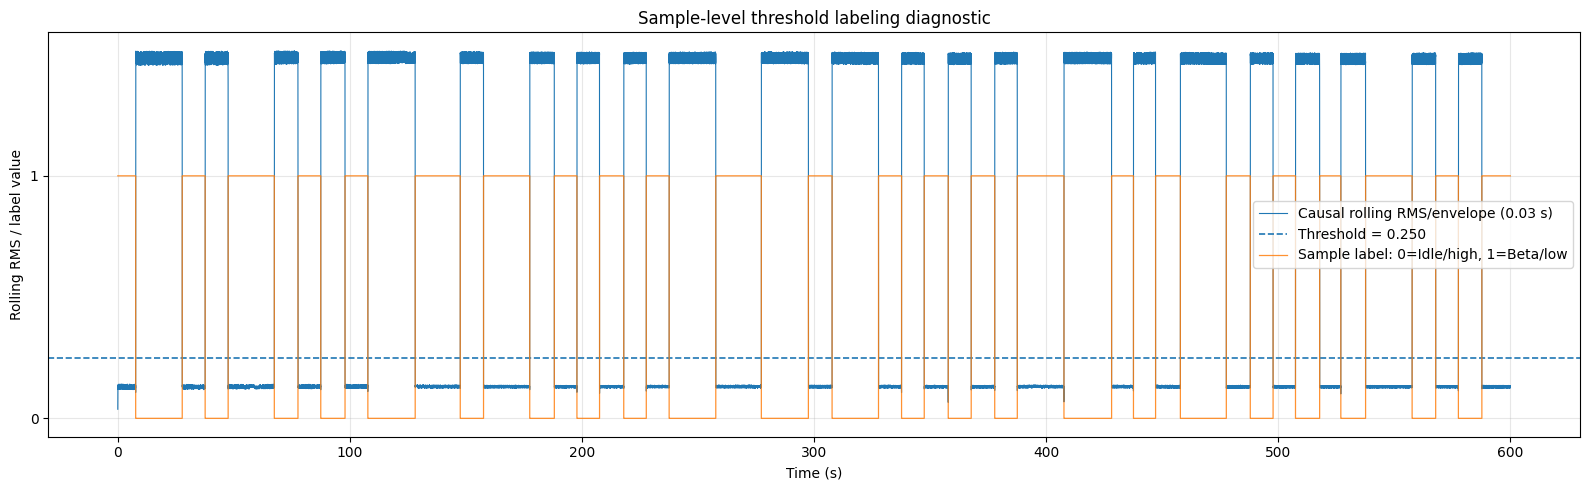

In [30]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    time,
    label_signal,
    linewidth=0.8,
    label=f'Causal rolling RMS/envelope ({rolling_rms_sec:.2f} s)',
)
ax.axhline(
    threshold,
    linestyle='--',
    linewidth=1.2,
    label=f'Threshold = {threshold:.3f}',
)
ax.step(
    time,
    sample_labels,
    where='post',
    linewidth=0.9,
    alpha=0.85,
    label='Sample label: 0=Idle/high, 1=Beta/low',
)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Rolling RMS / label value')
ax.set_title('Sample-level threshold labeling diagnostic')
ax.set_yticks([0, 1])
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Complete signal and inferred labels on the same axes

The complete continuous signal and the inferred sample-level labels are plotted on the **same axes** using different colors.


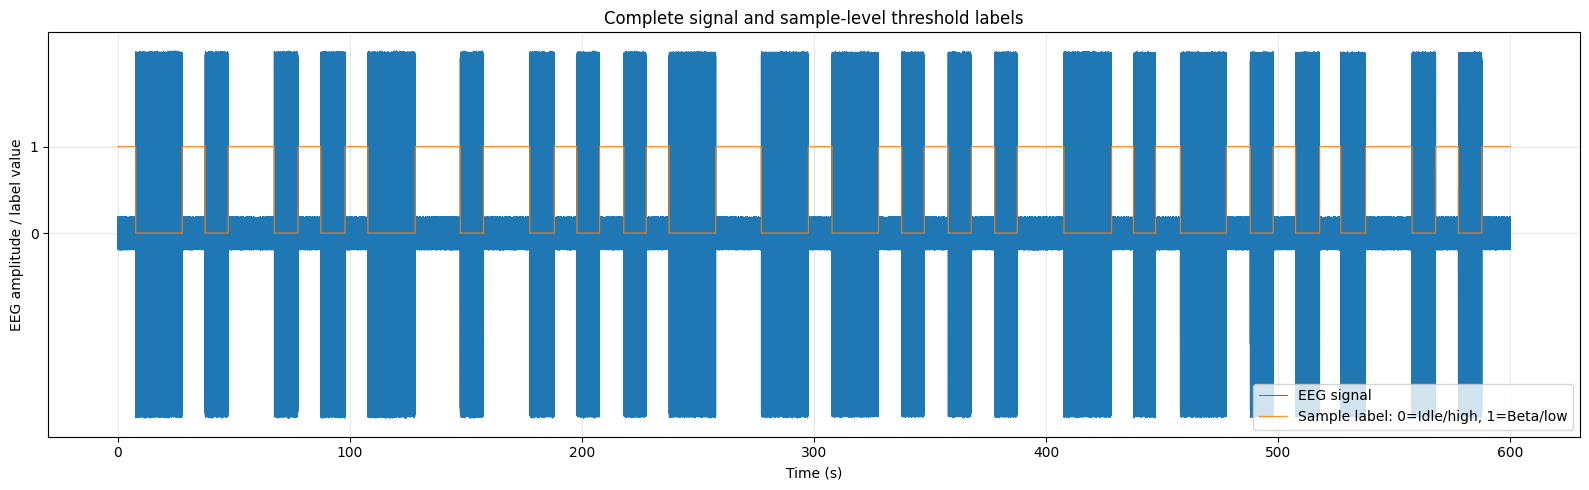

In [31]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    time,
    eeg,
    linewidth=0.7,
    label='EEG signal',
)
ax.step(
    time,
    sample_labels,
    where='post',
    linewidth=0.9,
    alpha=0.85,
    label='Sample label: 0=Idle/high, 1=Beta/low',
)

ax.set_xlabel('Time (s)')
ax.set_ylabel('EEG amplitude / label value')
ax.set_title('Complete signal and sample-level threshold labels')
ax.set_yticks([0, 1])
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Zoomed same-axis view

Because the full 10-minute signal is dense, the figure below shows a zoomed-in view of the first 30 seconds, again with the signal and labels on the **same axes**.


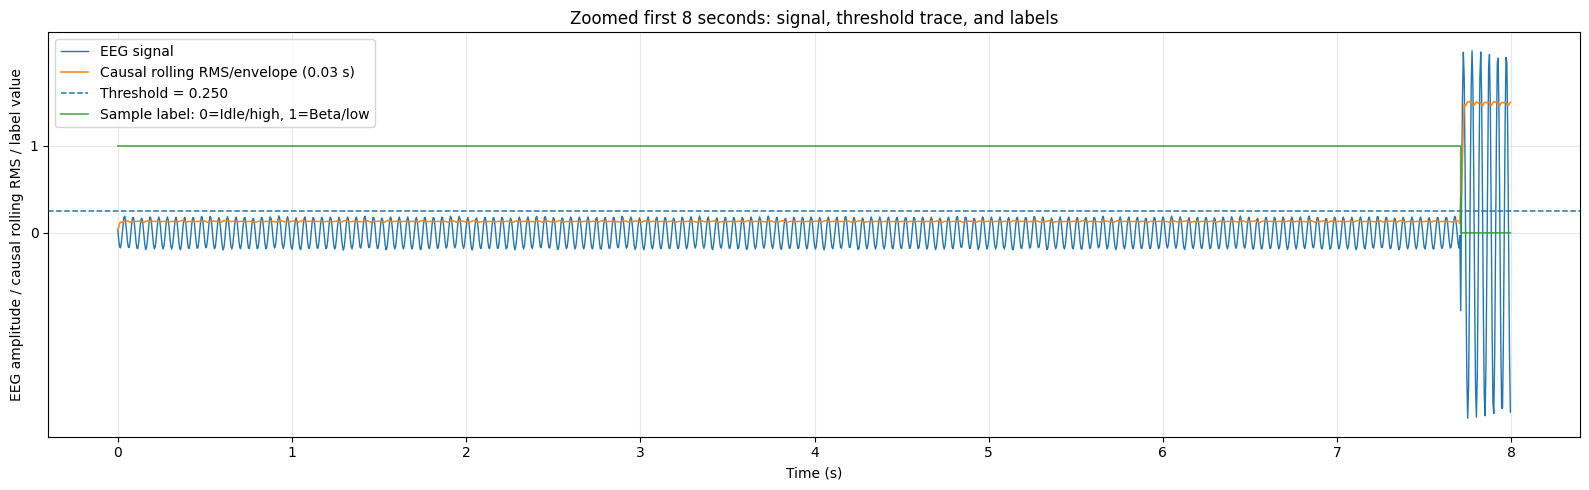

In [32]:
zoom_sec = 8
n_zoom = int(zoom_sec * fs)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    time[:n_zoom],
    eeg[:n_zoom],
    linewidth=1.0,
    label='EEG signal',
)
ax.plot(
    time[:n_zoom],
    label_signal[:n_zoom],
    linewidth=1.2,
    alpha=0.9,
    label=f'Causal rolling RMS/envelope ({rolling_rms_sec:.2f} s)',
)
ax.axhline(
    threshold,
    linestyle='--',
    linewidth=1.1,
    label=f'Threshold = {threshold:.3f}',
)
ax.step(
    time[:n_zoom],
    sample_labels[:n_zoom],
    where='post',
    linewidth=1.2,
    alpha=0.85,
    label='Sample label: 0=Idle/high, 1=Beta/low',
)

ax.set_xlabel('Time (s)')
ax.set_ylabel('EEG amplitude / causal rolling RMS / label value')
ax.set_title(f'Zoomed first {zoom_sec} seconds: signal, threshold trace, and labels')
ax.set_yticks([0, 1])
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()